## Configuración del entorno

### Instalación de librerias adicionales

In [ ]:
# Instalación de librerías adicionales si es necesario
!pip install pandas numpy matplotlib seaborn plotly --quiet

print("Librerías instaladas correctamente")

Librerías instaladas correctamente


### Importación de bibliotecas

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings



# Configuración de visualización
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Configuración de tamaños de figura por defecto
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Bibliotecas importadas correctamente")
print(f"Versión de pandas: {pd.__version__}")
print(f"Versión de numpy: {np.__version__}")
import kagglehub

Bibliotecas importadas correctamente
Versión de pandas: 2.2.2
Versión de numpy: 2.0.2


## Carga de los dataset

### Obtener el path directamente de kaggle

In [ ]:
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Path to dataset files: /kaggle/input/brazilian-ecommerce


### Descargar los dataset

In [ ]:
df_customers = pd.read_csv(path + "/olist_customers_dataset.csv")
df_geolocation = pd.read_csv(path + "/olist_geolocation_dataset.csv")
df_items = pd.read_csv(path + "/olist_order_items_dataset.csv")
df_payments = pd.read_csv(path + "/olist_order_payments_dataset.csv")
df_reviews = pd.read_csv(path + "/olist_order_reviews_dataset.csv")
df_orders = pd.read_csv(path + "/olist_orders_dataset.csv")
df_products = pd.read_csv(path + "/olist_products_dataset.csv")
df_sellers = pd.read_csv(path + "/olist_sellers_dataset.csv")
df_product_category = pd.read_csv(path + "/product_category_name_translation.csv")

## 1. Desnormalización

### Merge orders - customers

In [ ]:
print("df_orders")
print("=" * 80)
display(df_orders.head())
print(f"Dimensiones del dataset df_orders: {df_orders.shape[0]:,} filas × {df_orders.shape[1]} columnas")
print("=" * 320)
print("df_customers")
print("=" * 80)
display(df_customers.head())
print(f"Dimensiones del dataset df_customers: {df_customers.shape[0]:,} filas × {df_customers.shape[1]} columnas")
print("=" * 320)
print("df_orders_customers")
print("=" * 80)
df_orders_customers = df_orders.merge(df_customers,on="customer_id",how="left")
display(df_orders_customers.head())
print(f"Dimensiones del dataset df_orders_customers: {df_orders_customers.shape[0]:,} filas × {df_orders_customers.shape[1]} columnas")
print("=" * 320)



df_orders


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


Dimensiones del dataset df_orders: 99,441 filas × 8 columnas
df_customers


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


Dimensiones del dataset df_customers: 99,441 filas × 5 columnas
df_orders_customers


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


Dimensiones del dataset df_orders_customers: 99,441 filas × 12 columnas


### Merge orders_customers - items

In [ ]:
print("df_orders_customers")
print("=" * 80)
display(df_orders_customers.head())
print(f"Dimensiones del dataset df_orders_customers: {df_orders_customers.shape[0]:,} filas × {df_orders_customers.shape[1]} columnas")
print("=" * 320)
print("df_items")
print("=" * 80)
display(df_items.head())
print(f"Dimensiones del dataset df_items: {df_items.shape[0]:,} filas × {df_items.shape[1]} columnas")
print("=" * 320)
print("df_orders_items")
print("=" * 80)
df_orders_items = df_orders_customers.merge(df_items,on="order_id",how="left")
display(df_orders_items.head())
print(f"Dimensiones del dataset df_orders_items: {df_orders_items.shape[0]:,} filas × {df_orders_items.shape[1]} columnas")
print("=" * 320)

df_orders_customers


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


Dimensiones del dataset df_orders_customers: 99,441 filas × 12 columnas
df_items


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


Dimensiones del dataset df_items: 112,650 filas × 7 columnas
df_orders_items


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72


Dimensiones del dataset df_orders_items: 113,425 filas × 18 columnas


### Merge orders_items - products


In [ ]:
print("df_orders_items")
print("=" * 80)
display(df_orders_items.head())
print(f"Dimensiones del dataset df_orders_items: {df_orders_items.shape[0]:,} filas × {df_orders_items.shape[1]} columnas")
print("=" * 320)
print("df_products")
print("=" * 80)
display(df_products.head())
print(f"Dimensiones del dataset df_products: {df_products.shape[0]:,} filas × {df_products.shape[1]} columnas")
print("=" * 320)
print("df_orders_products")
print("=" * 80)
df_orders_products = df_orders_items.merge(df_products,on="product_id",how="left")
display(df_orders_products.head())
print(f"Dimensiones del dataset df_orders_products: {df_orders_products.shape[0]:,} filas × {df_orders_products.shape[1]} columnas")
print("=" * 320)

df_orders_items


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72


Dimensiones del dataset df_orders_items: 113,425 filas × 18 columnas
df_products


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


Dimensiones del dataset df_products: 32,951 filas × 9 columnas
df_orders_products


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0


Dimensiones del dataset df_orders_products: 113,425 filas × 26 columnas


### Merge orders_products - sellers

In [ ]:
print("df_orders_products")
print("=" * 80)
display(df_orders_products.head())
print(f"Dimensiones del dataset df_orders_products: {df_orders_products.shape[0]:,} filas × {df_orders_products.shape[1]} columnas")
print("=" * 320)
print("df_sellers")
print("=" * 80)
display(df_sellers.head())
print(f"Dimensiones del dataset df_sellers: {df_sellers.shape[0]:,} filas × {df_sellers.shape[1]} columnas")
print("=" * 320)
print("df_orders_products")
print("=" * 80)
df_orders_sellers = df_orders_products.merge(df_sellers,on="seller_id",how="left")
display(df_orders_sellers.head())
print(f"Dimensiones del dataset df_orders_sellers: {df_orders_sellers.shape[0]:,} filas × {df_orders_sellers.shape[1]} columnas")
print("=" * 320)

df_orders_products


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0


Dimensiones del dataset df_orders_products: 113,425 filas × 26 columnas
df_sellers


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


Dimensiones del dataset df_sellers: 3,095 filas × 4 columnas
df_orders_products


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,31570.0,belo horizonte,SP
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,14840.0,guariba,SP
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,31842.0,belo horizonte,MG
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,8752.0,mogi das cruzes,SP


Dimensiones del dataset df_orders_sellers: 113,425 filas × 29 columnas


### Merge orders_sellers - payments

#### Agrupar pagos por pedido

In [ ]:
# Como cada pedido se pudo hacer con varios pagos, se agruparon sumando los pagos de cada pedido, y las cuotas, se tomo el valor de la cuota maxima
print("df_payments")
print("=" * 80)
display(df_payments.head())
print(f"Dimensiones del dataset df_payments: {df_payments.shape[0]:,} filas × {df_payments.shape[1]} columnas")
print("=" * 320)
df_payments_grouped = (
    df_payments
    .groupby("order_id")
    .agg({
        "payment_value": "sum",
        "payment_installments": "max"
    })
    .reset_index()
)
print("df_payments_grouped")
print("=" * 80)
display(df_payments_grouped.head())
print(f"Dimensiones del dataset df_payments_grouped: {df_payments_grouped.shape[0]:,} filas × {df_payments_grouped.shape[1]} columnas")

df_payments


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


Dimensiones del dataset df_payments: 103,886 filas × 5 columnas
df_payments_grouped


,order_id,payment_value,payment_installments
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,2
1,00018f77f2f0320c557190d7a144bdd3,259.83,3
2,000229ec398224ef6ca0657da4fc703e,216.87,5
3,00024acbcdf0a6daa1e931b038114c75,25.78,2
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,3


Dimensiones del dataset df_payments_grouped: 99,440 filas × 3 columnas


#### Merge orders_sellers - payments_grouped

In [ ]:
print("df_orders_sellers")
print("=" * 80)
display(df_orders_sellers.head())
print(f"Dimensiones del dataset df_orders_sellers: {df_orders_sellers.shape[0]:,} filas × {df_orders_sellers.shape[1]} columnas")
print("=" * 320)
print("df_payments_grouped")
print("=" * 80)
display(df_payments_grouped.head())
print(f"Dimensiones del dataset df_payments_grouped: {df_payments_grouped.shape[0]:,} filas × {df_payments_grouped.shape[1]} columnas")
print("=" * 320)
print("df_orders_payments")
print("=" * 80)
df_orders_payments = df_orders_sellers.merge(df_payments_grouped,on="order_id",how="left")
display(df_orders_payments.head())
print(f"Dimensiones del dataset df_orders_payments: {df_orders_payments.shape[0]:,} filas × {df_orders_payments.shape[1]} columnas")
print("=" * 320)

df_orders_sellers


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,31570.0,belo horizonte,SP
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,14840.0,guariba,SP
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,31842.0,belo horizonte,MG
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,8752.0,mogi das cruzes,SP


Dimensiones del dataset df_orders_sellers: 113,425 filas × 29 columnas
df_payments_grouped


,order_id,payment_value,payment_installments
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,2
1,00018f77f2f0320c557190d7a144bdd3,259.83,3
2,000229ec398224ef6ca0657da4fc703e,216.87,5
3,00024acbcdf0a6daa1e931b038114c75,25.78,2
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,3


Dimensiones del dataset df_payments_grouped: 99,440 filas × 3 columnas
df_orders_payments


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,payment_value,payment_installments
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP,38.71,1.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,31570.0,belo horizonte,SP,141.46,1.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,14840.0,guariba,SP,179.12,3.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,31842.0,belo horizonte,MG,72.20,1.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,8752.0,mogi das cruzes,SP,28.62,1.0


Dimensiones del dataset df_orders_payments: 113,425 filas × 31 columnas


### Merge orders_payments - reviews


#### Agrupar reviews por pedido

In [ ]:
#Se agrupan los reviews por pedido, promediando la calificación por pedido
print("df_reviews")
print("=" * 80)
display(df_reviews.head())
print(f"Dimensiones del dataset df_reviews: {df_reviews.shape[0]:,} filas × {df_reviews.shape[1]} columnas")
print("=" * 320)
df_reviews_grouped = (
    df_reviews
    .groupby("order_id")
    .agg({
        "review_score": "mean"
    })
    .reset_index()
)
print("df_reviews_grouped")
print("=" * 80)
display(df_reviews_grouped.head())
print(f"Dimensiones del dataset df_reviews_grouped: {df_reviews_grouped.shape[0]:,} filas × {df_reviews_grouped.shape[1]} columnas")

df_reviews


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


Dimensiones del dataset df_reviews: 99,224 filas × 7 columnas
df_reviews_grouped


,order_id,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,5.0
1,00018f77f2f0320c557190d7a144bdd3,4.0
2,000229ec398224ef6ca0657da4fc703e,5.0
3,00024acbcdf0a6daa1e931b038114c75,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.0


Dimensiones del dataset df_reviews_grouped: 98,673 filas × 2 columnas


#### Merge orders_payments - reviews_grouped

In [ ]:
print("df_orders_payments")
print("=" * 80)
display(df_orders_payments.head())
print(f"Dimensiones del dataset df_orders_payments: {df_orders_payments.shape[0]:,} filas × {df_orders_payments.shape[1]} columnas")
print("=" * 320)
print("df_reviews_grouped")
print("=" * 80)
display(df_reviews_grouped.head())
print(f"Dimensiones del dataset df_reviews_grouped: {df_reviews_grouped.shape[0]:,} filas × {df_reviews_grouped.shape[1]} columnas")
print("=" * 320)
print("df_orders_reviews")
print("=" * 80)
df_orders_reviews = df_orders_payments.merge(df_reviews_grouped,on="order_id",how="left")
display(df_orders_reviews.head())
print(f"Dimensiones del dataset df_orders_reviews: {df_orders_reviews.shape[0]:,} filas × {df_orders_reviews.shape[1]} columnas")
print("=" * 320)

df_orders_payments


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,payment_value,payment_installments
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP,38.71,1.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,31570.0,belo horizonte,SP,141.46,1.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,14840.0,guariba,SP,179.12,3.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,31842.0,belo horizonte,MG,72.20,1.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,8752.0,mogi das cruzes,SP,28.62,1.0


Dimensiones del dataset df_orders_payments: 113,425 filas × 31 columnas
df_reviews_grouped


,order_id,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,5.0
1,00018f77f2f0320c557190d7a144bdd3,4.0
2,000229ec398224ef6ca0657da4fc703e,5.0
3,00024acbcdf0a6daa1e931b038114c75,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.0


Dimensiones del dataset df_reviews_grouped: 98,673 filas × 2 columnas
df_orders_reviews


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,payment_value,payment_installments,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP,38.71,1.0,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,31570.0,belo horizonte,SP,141.46,1.0,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,14840.0,guariba,SP,179.12,3.0,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,31842.0,belo horizonte,MG,72.20,1.0,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,8752.0,mogi das cruzes,SP,28.62,1.0,5.0


Dimensiones del dataset df_orders_reviews: 113,425 filas × 32 columnas


### Merge orders_reviews - category

In [ ]:
print("df_orders_reviews")
print("=" * 80)
display(df_orders_reviews.head())
print(f"Dimensiones del dataset df_orders_reviews: {df_orders_reviews.shape[0]:,} filas × {df_orders_reviews.shape[1]} columnas")
print("=" * 320)
print("df_product_category")
print("=" * 80)
display(df_product_category.head())
print(f"Dimensiones del dataset df_product_category: {df_product_category.shape[0]:,} filas × {df_product_category.shape[1]} columnas")
print("=" * 320)
print("df_orders_category")
print("=" * 80)
df_orders_category = df_orders_reviews.merge(df_product_category,on="product_category_name",how="left")
display(df_orders_category.head())
print(f"Dimensiones del dataset df_orders_category: {df_orders_category.shape[0]:,} filas × {df_orders_category.shape[1]} columnas")
print("=" * 320)

df_orders_reviews


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,payment_value,payment_installments,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP,38.71,1.0,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,31570.0,belo horizonte,SP,141.46,1.0,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,14840.0,guariba,SP,179.12,3.0,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,31842.0,belo horizonte,MG,72.20,1.0,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,8752.0,mogi das cruzes,SP,28.62,1.0,5.0


Dimensiones del dataset df_orders_reviews: 113,425 filas × 32 columnas
df_product_category


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


Dimensiones del dataset df_product_category: 71 filas × 2 columnas
df_orders_category


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,payment_value,payment_installments,review_score,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP,38.71,1.0,4.0,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,31570.0,belo horizonte,SP,141.46,1.0,4.0,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,14840.0,guariba,SP,179.12,3.0,5.0,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,31842.0,belo horizonte,MG,72.20,1.0,5.0,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,8752.0,mogi das cruzes,SP,28.62,1.0,5.0,stationery


Dimensiones del dataset df_orders_category: 113,425 filas × 33 columnas


## Dataset final (desnormalizado)

In [ ]:
print("=" * 320)
print("df_orders_category")
print("=" * 80)
df_orders_category = df_orders_reviews.merge(df_product_category,on="product_category_name",how="left")
display(df_orders_category.head())
print(f"Dimensiones del dataset df_orders_category: {df_orders_category.shape[0]:,} filas × {df_orders_category.shape[1]} columnas")
print("=" * 320)
df_orders_category.columns

df_orders_category


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,payment_value,payment_installments,review_score,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP,38.71,1.0,4.0,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,31570.0,belo horizonte,SP,141.46,1.0,4.0,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,14840.0,guariba,SP,179.12,3.0,5.0,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,31842.0,belo horizonte,MG,72.20,1.0,5.0,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,8752.0,mogi das cruzes,SP,28.62,1.0,5.0,stationery


Dimensiones del dataset df_orders_category: 113,425 filas × 33 columnas


Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'seller_zip_code_prefix', 'seller_city', 'seller_state',
       'payment_value', 'payment_installments', 'review_score',
       'product_category_name_english'],
      dtype='object')

## 2. Análisis de calidad de datos

### Duplicados

In [ ]:
print(" ANÁLISIS DE DUPLICADOS")
print("=" * 80)

# 1. Duplicados completos
n_total_duplicates = df_orders_category.duplicated().sum()
pct_total_duplicates = (n_total_duplicates / len(df_orders_category) * 100)

print(f"\n1️.  Registros completamente duplicados:")
print(f"    Cantidad: {n_total_duplicates:,} ({pct_total_duplicates:.2f}%)")

# 2. Duplicados por order_id
n_order_duplicates = df_orders_category['order_id'].duplicated().sum()
pct_order_duplicates = (n_order_duplicates / len(df_orders_category) * 100)

print(f"\n2️.  Pedidos duplicados (mismo order_id):")
print(f"    Cantidad: {n_order_duplicates:,} ({pct_order_duplicates:.2f}%)")

# 3. Duplicados por customer_id
n_customer_duplicates = df_orders_category['customer_id'].duplicated().sum()
pct_customer_duplicates = (n_customer_duplicates / len(df_orders_category) * 100)

print(f"\n3.  Clientes duplicados (mismo customer_id):")
print(f"    Cantidad: {n_customer_duplicates:,} ({pct_customer_duplicates:.2f}%)")

# 3. Duplicados por product_id
n_product_duplicates = df_orders_category['product_id'].duplicated().sum()
pct_product_duplicates = (n_product_duplicates / len(df_orders_category) * 100)

print(f"\n4.  Productos duplicados (mismo product_id):")
print(f"    Cantidad: {n_product_duplicates:,} ({pct_product_duplicates:.2f}%)")

# 3. Duplicados por seller_id
n_seller_duplicates = df_orders_category['seller_id'].duplicated().sum()
pct_seller_duplicates = (n_seller_duplicates / len(df_orders_category) * 100)

# 3. Duplicados por order_item_id
n_order_item_duplicates = df_orders_category.duplicated(subset=["order_id", "order_item_id"]).sum()
pct_order_item_duplicates = (n_order_item_duplicates / len(df_orders_category) * 100)

print(f"\n5.  items + pedidos duplicados (mismo order_item_id + order_id):")
print(f"    Cantidad: {n_order_item_duplicates:,} ({pct_order_item_duplicates:.2f}%)")

print(f"\n6. No hay registros completamente duplicados en la tabla final ")
print(f"\n7. Los 13.984 pedidos duplicados se deben a que un pedido tiene varios items")
print(f"\n8. La cantidad de clientes duplicados es la misma de pedidos duplicados, un cliente puede tener varios pedidos")
print(f"\n9. La cantidad de productos duplicados es alta, un producto puede estar en varios pedidos")
print(f"\n10. En la clave compuesta no hay duplicados, cada fila representa un item unico dentro de un pedido")




 ANÁLISIS DE DUPLICADOS

1️.  Registros completamente duplicados:
    Cantidad: 0 (0.00%)

2️.  Pedidos duplicados (mismo order_id):
    Cantidad: 13,984 (12.33%)

3.  Clientes duplicados (mismo customer_id):
    Cantidad: 13,984 (12.33%)

4.  Productos duplicados (mismo product_id):
    Cantidad: 80,473 (70.95%)

5.  items + pedidos duplicados (mismo order_item_id + order_id):
    Cantidad: 0 (0.00%)

6. No hay registros completamente duplicados en la tabla final 

7. Los 13.984 pedidos duplicados se deben a que un pedido tiene varios items

8. La cantidad de clientes duplicados es la misma de pedidos duplicados, un cliente puede tener varios pedidos

9. La cantidad de productos duplicados es alta, un producto puede estar en varios pedidos

10. En la clave compuesta no hay duplicados, cada fila representa un item unico dentro de un pedido


##3. Distribuciones

### Distribución de productos

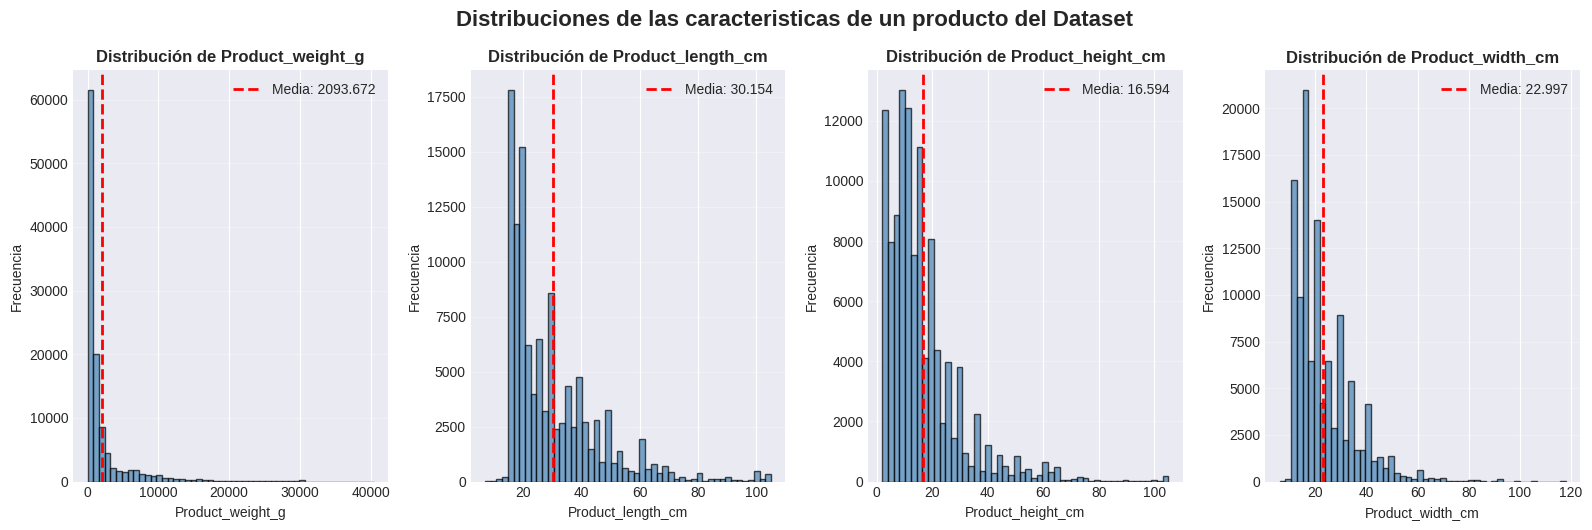

In [ ]:
# Caracteristicas de un producto
money_features = ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

# Crear subplots
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
axes = axes.ravel()

for idx, feature in enumerate(money_features):
    axes[idx].hist(df_orders_category[feature], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribución de {feature.capitalize()}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(feature.capitalize(), fontsize=10)
    axes[idx].set_ylabel('Frecuencia', fontsize=10)
    axes[idx].grid(axis='y', alpha=0.3)

    # Agregar línea de media
    mean_val = df_orders_category[feature].mean()
    axes[idx].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Media: {mean_val:.3f}')
    axes[idx].legend()

# Eliminar subplots vacíos
for idx in range(len(df_orders_category), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.suptitle('Distribuciones de las caracteristicas de un producto del Dataset',
             fontsize=16, fontweight='bold', y=1.05)
plt.show()

### Distribuciones de dinero

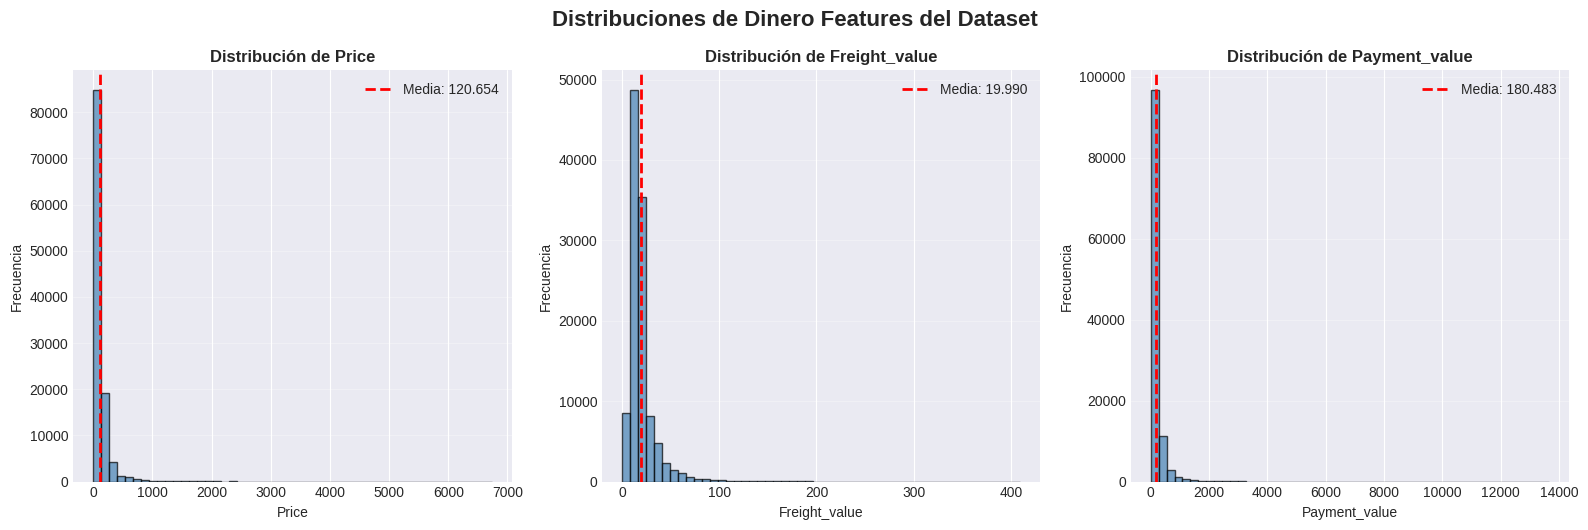

In [ ]:
# Seleccionar características de Dinero principales
money_features = ['price', 'freight_value', 'payment_value']

# Crear subplots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes = axes.ravel()

for idx, feature in enumerate(money_features):
    axes[idx].hist(df_orders_category[feature], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribución de {feature.capitalize()}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(feature.capitalize(), fontsize=10)
    axes[idx].set_ylabel('Frecuencia', fontsize=10)
    axes[idx].grid(axis='y', alpha=0.3)

    # Agregar línea de media
    mean_val = df_orders_category[feature].mean()
    axes[idx].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Media: {mean_val:.3f}')
    axes[idx].legend()

# Eliminar subplots vacíos
for idx in range(len(df_orders_category), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.suptitle('Distribuciones de Dinero Features del Dataset',
             fontsize=16, fontweight='bold', y=1.05)
plt.show()

##4. Análisis de relaciones entre entidades


### Identificación de entidades

En el contexto de diseño de bases de datos, se identifican siete entidades principales:
- **orders** (pedidos)
- **customers** (clientes)
- **items** (items)
- **products** (productos)
- **sellers** (vendedores)
- **payments** (pagos)
- **reviews** (opiniones)

Estas entidades están relacionadas de la siguiente forma:
- Cada pedido pertenece a un cliente y un cliente puede tener muchos pedidos.
- Un pedido puede tener varios productos
- Un pedido se puede pagar con varios medios de pago, pero para la desnormalización, se agruparon los medios de pago sumando el valor de cada pago.
- Un pedido puede tener varias review, por ello tambien se agrupo para que cada pedido solo tuviera un review.
- Muchos items pueden ser el mismo producto.
- Un vendedor vende muchos productos

In [ ]:
print("ANÁLISIS DE CARDINALIDAD ENTRE ENTIDADES")
print("=" * 80)

# Contar elementos únicos
n_order = df_orders_category['order_id'].nunique()
n_customer = df_orders_category['customer_id'].nunique()
n_product = df_orders_category['product_id'].nunique()
n_seller = df_orders_category['seller_id'].nunique()

print(f"\nCantidades únicas:")
print(f"   • Orders (pedidos):  {n_order:>8,}")
print(f"   • Customers (clientes):  {n_customer:>8,}")
print(f"   • Sellers (vendedores):  {n_seller:>8,}")
print(f"   • Products (productos):  {n_product:>8,}")

# Análisis de relaciones
orders_per_customers = df_orders_category.groupby('customer_id')['order_id'].nunique()
orders_per_product = df_orders_category.groupby('product_id')['order_id'].nunique()
orders_per_sellers = df_orders_category.groupby('seller_id')['order_id'].nunique()
products_per_seller = df_orders_category.groupby('product_id')['seller_id'].nunique()


print(f"\nRelaciones promedio:")
print(f"   • Customer por Orders:    {orders_per_customers.mean():>8.2f} (promedio)")
print(f"   • Product por Orders:    {orders_per_product.mean():>8.2f} (promedio)")
print(f"   • Seller por Orders:    {orders_per_sellers.mean():>8.2f} (promedio)")

print(f"\nValores extremos:")
print(f"   • Máximo de productos en un pedido:   {orders_per_product.max()}")
print(f"   • Máximo de vendedores por pedido:   {orders_per_sellers.max()}")
print(f"   • Máximo de clientes por pedido:   {orders_per_customers.max()}")



ANÁLISIS DE CARDINALIDAD ENTRE ENTIDADES

Cantidades únicas:
   • Orders (pedidos):    99,441
   • Customers (clientes):    99,441
   • Sellers (vendedores):     3,095
   • Products (productos):    32,951

Relaciones promedio:
   • Customer por Orders:        1.00 (promedio)
   • Product por Orders:        3.11 (promedio)
   • Seller por Orders:       32.31 (promedio)

Valores extremos:
   • Máximo de productos en un pedido:   467
   • Máximo de vendedores por pedido:   1854
   • Máximo de clientes por pedido:   1


### Categorias de productos mas vendidos

TOP 15 CATEGORIAS DE PRODUCTOS MAS VENDIDAS
 1. cama_mesa_banho                          11115 
 2. beleza_saude                             9670 
 3. esporte_lazer                            8641 
 4. moveis_decoracao                         8334 
 5. informatica_acessorios                   7827 
 6. utilidades_domesticas                    6964 
 7. relogios_presentes                       5991 
 8. telefonia                                4545 
 9. ferramentas_jardim                       4347 
10. automotivo                               4235 
11. brinquedos                               4117 
12. cool_stuff                               3796 
13. perfumaria                               3419 
14. bebes                                    3065 
15. eletronicos                              2767 


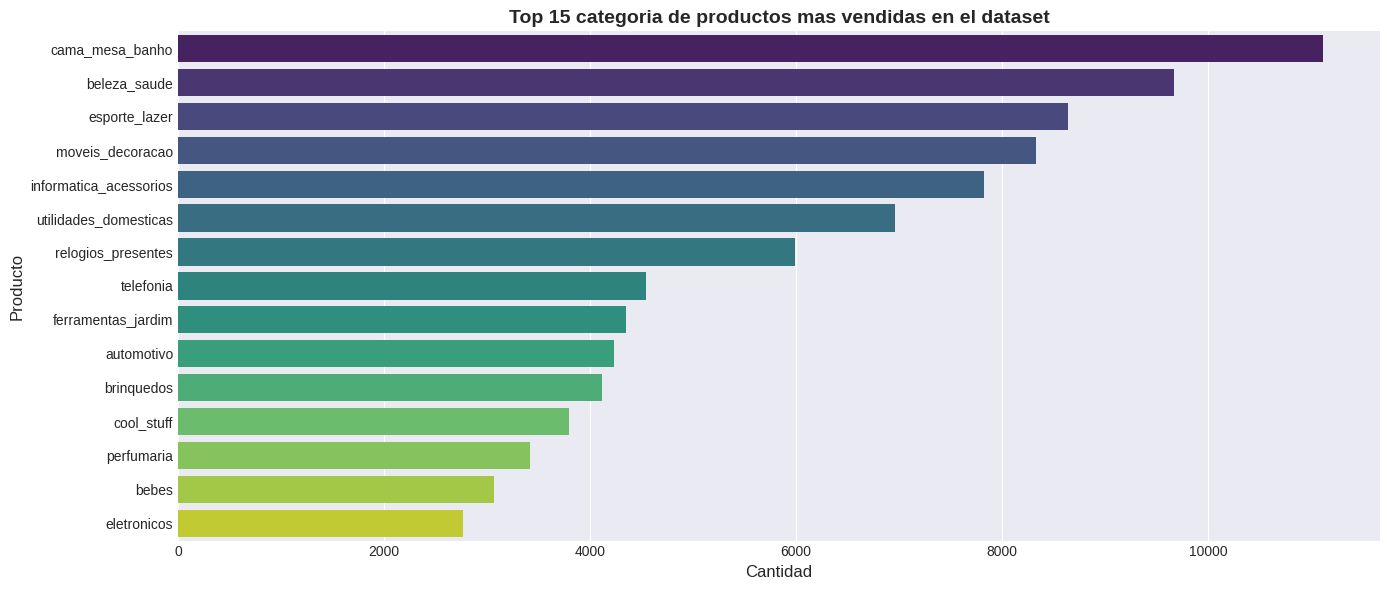

In [ ]:
# Top 15 productos mas vendidos
top_products = df_orders_category['product_category_name'].value_counts().head(15)

print("TOP 15 CATEGORIAS DE PRODUCTOS MAS VENDIDAS")
print("=" * 80)

for idx, (products, count) in enumerate(top_products.items(), 1):
    print(f"{idx:>2}. {products:<40} {count:>4} ")

# Visualización
plt.figure(figsize=(14, 6))
sns.barplot(x=top_products.values, y=top_products.index, palette='viridis')
plt.xlabel('Cantidad', fontsize=12)
plt.ylabel('Producto', fontsize=12)
plt.title('Top 15 categoria de productos mas vendidas en el dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

##5 Valores nulos

ANÁLISIS DE VALORES NULOS

  Columnas con valores nulos detectados:

                      Columna  Valores nulos  Porcentaje (%)
order_delivered_customer_date           3229            2.85
product_category_name_english           2402            2.12
        product_category_name           2378            2.10
   product_description_lenght           2378            2.10
          product_name_lenght           2378            2.10
           product_photos_qty           2378            2.10
 order_delivered_carrier_date           1968            1.74
                 review_score            961            0.85
             product_width_cm            793            0.70
            product_height_cm            793            0.70
            product_length_cm            793            0.70
             product_weight_g            793            0.70
                   product_id            775            0.68
                order_item_id            775            0.68
                

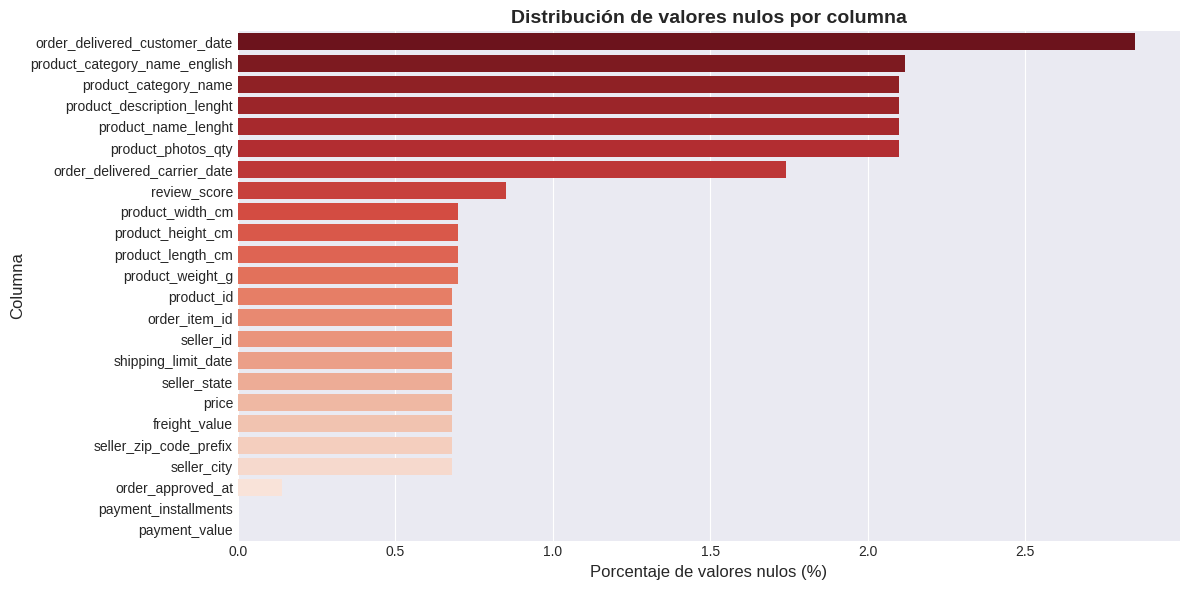

In [ ]:
print("ANÁLISIS DE VALORES NULOS")
print("=" * 80)

# Calcular valores nulos
null_counts = df_orders_category.isnull().sum()
null_percentages = (null_counts / len(df_orders_category) * 100).round(2)

# Crear DataFrame de resumen
null_summary = pd.DataFrame({
    'Columna': null_counts.index,
    'Valores nulos': null_counts.values,
    'Porcentaje (%)': null_percentages.values
})

# Filtrar solo columnas con valores nulos
null_summary = null_summary[null_summary['Valores nulos'] > 0].sort_values('Valores nulos', ascending=False)

if len(null_summary) > 0:
    print("\n  Columnas con valores nulos detectados:\n")
    print(null_summary.to_string(index=False))

    # Visualización
    if len(null_summary) > 0:
        plt.figure(figsize=(12, 6))
        sns.barplot(data=null_summary, x='Porcentaje (%)', y='Columna', palette='Reds_r')
        plt.xlabel('Porcentaje de valores nulos (%)', fontsize=12)
        plt.ylabel('Columna', fontsize=12)
        plt.title('Distribución de valores nulos por columna', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
else:
    print("\n No se detectaron valores nulos en el dataset")
    print("   Todos los registros están completos en todas las columnas")

### Detención de anomalías

#### Anomalías por valores imposibles

In [ ]:
#Análisis de las columnas numericas que no pueden ser menor o igual a 0
cols_num_positive = [
    'price','freight_value','payment_value',
    'order_item_id','payment_installments','product_photos_qty',
    'product_weight_g','product_length_cm','product_height_cm','product_width_cm',
    'product_name_lenght','product_description_lenght',
    'customer_zip_code_prefix','seller_zip_code_prefix'
]

for col in cols_num_positive:
    invalid = (df_orders_category[col] < 0).sum()
    print(f"{col}: {invalid} valores inválidos")

#Análisis de las columnas de puntuación que deben estar en el rango de 1 a 5 no mas
invalid_reviews = df_orders_category[(df_orders_category['review_score'] < 1) | (df_orders_category['review_score'] > 5)]
print("\nreview_score inválidos:", len(invalid_reviews), "\n")

#Análisis de fechas que no pueden ser mayores a la fecha actual
date_cols = [
    'order_purchase_timestamp','order_approved_at',
    'order_delivered_carrier_date','order_delivered_customer_date',
    'order_estimated_delivery_date','shipping_limit_date'
]

df_orders_category[date_cols] = df_orders_category[date_cols].apply(pd.to_datetime)

today = pd.Timestamp.today()

for col in date_cols:
    invalid = (df_orders_category[col] > today).sum()
    print(f"{col}: {invalid} fechas futuras")

#Coherencia entre fechas
print("\nAprobación antes de compra:",
      (df_orders_category['order_approved_at'] < df_orders_category['order_purchase_timestamp']).sum())

print("Envío antes de compra:",
      (df_orders_category['order_delivered_carrier_date'] < df_orders_category['order_purchase_timestamp']).sum())

print("Entrega antes de compra:",
      (df_orders_category['order_delivered_customer_date'] < df_orders_category['order_purchase_timestamp']).sum())



price: 0 valores inválidos
freight_value: 0 valores inválidos
payment_value: 0 valores inválidos
order_item_id: 0 valores inválidos
payment_installments: 0 valores inválidos
product_photos_qty: 0 valores inválidos
product_weight_g: 0 valores inválidos
product_length_cm: 0 valores inválidos
product_height_cm: 0 valores inválidos
product_width_cm: 0 valores inválidos
product_name_lenght: 0 valores inválidos
product_description_lenght: 0 valores inválidos
customer_zip_code_prefix: 0 valores inválidos
seller_zip_code_prefix: 0 valores inválidos

review_score inválidos: 0 

order_purchase_timestamp: 0 fechas futuras
order_approved_at: 0 fechas futuras
order_delivered_carrier_date: 0 fechas futuras
order_delivered_customer_date: 0 fechas futuras
order_estimated_delivery_date: 0 fechas futuras
shipping_limit_date: 0 fechas futuras

Aprobación antes de compra: 0
Envío antes de compra: 187
Entrega antes de compra: 0


## 6. Outliers

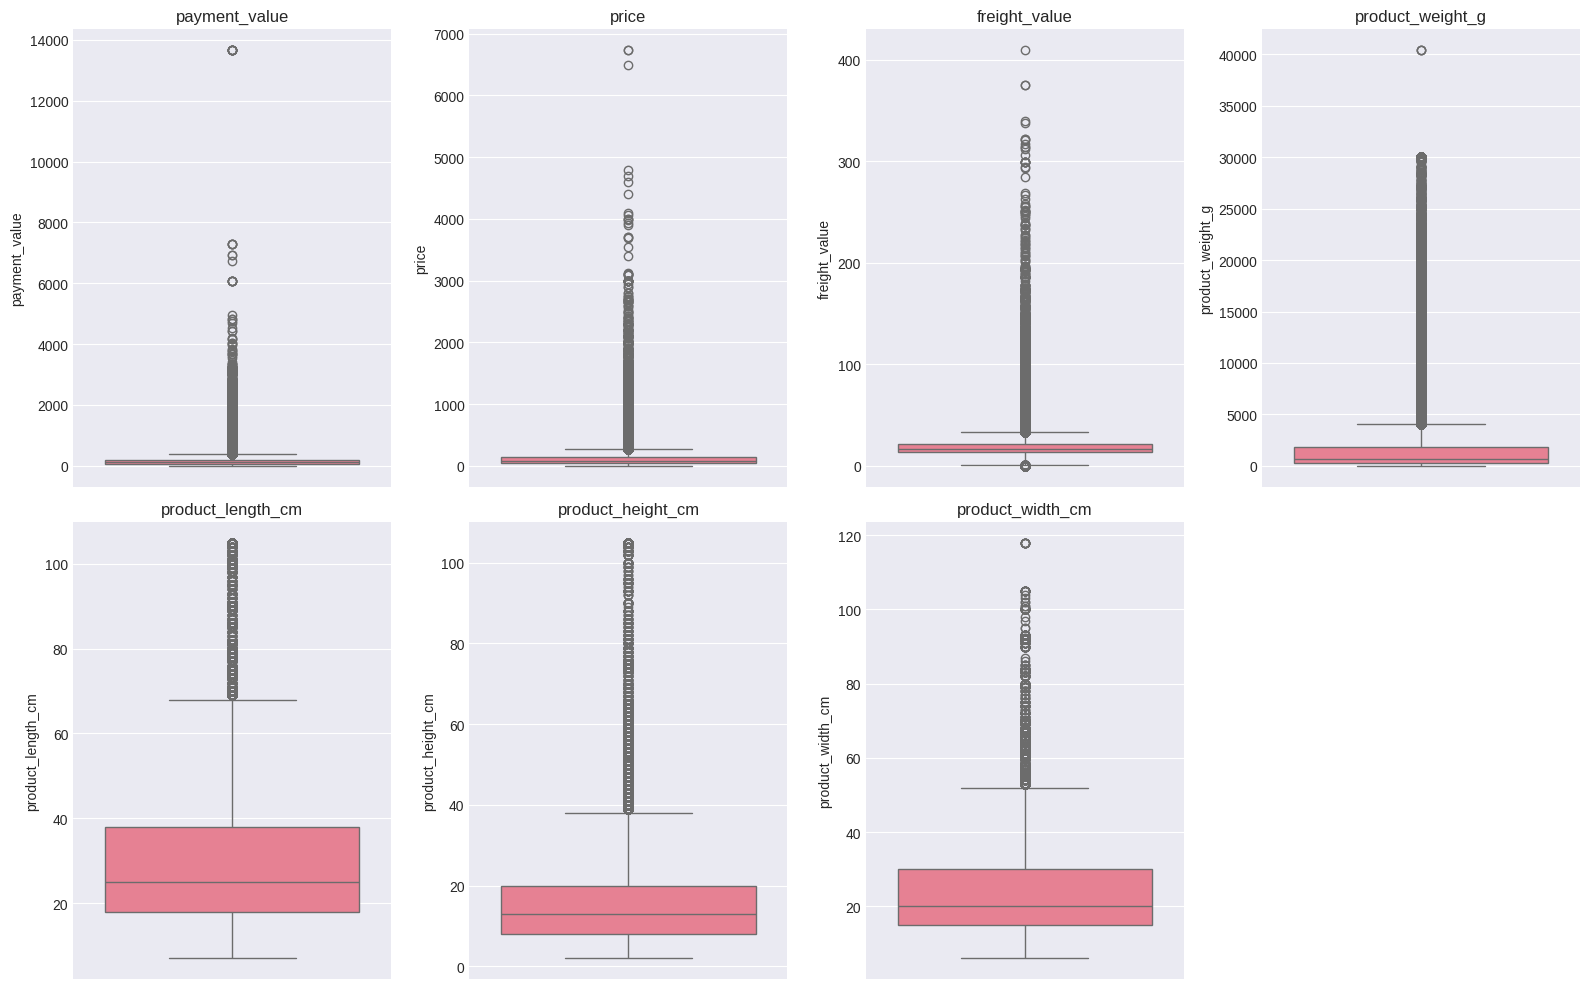

In [ ]:
cols = ["payment_value", "price", "freight_value",
        "product_weight_g", "product_length_cm",
        "product_height_cm", "product_width_cm"]

plt.figure(figsize=(16, 10))

for i, col in enumerate(cols):
    plt.subplot(2, 4, i+1)
    sns.boxplot(y=df_orders_category[col])
    plt.title(col)
    plt.tight_layout()

plt.show()

###Descripción de los Outlers
**payment_value:** En esta gráfica se observa que los pagos realizados se concentran entre 0 a 500. Se observa que hay varios outlers en la parte alta que refleja compras de alto valor. Y el outler cercano a los 14000, es un valor que se debe analizar.

**price:** Tiene un comportamiento parecido a payment_value, pero aqui los precios se concentran en el rango de 0 a 300, y el outler del extremo se encuentra cerca de los 7000.

**freight_value:** De las columnas analizadas, es la unica que tiene outlers antes o sobre el bigote inferior, cercano a 0. El valor del pedido se concentra entre 0 y 40 y tiene outlers que superan los 400.

##7. Patrones temporales / geográficos

###Patrones geográficos

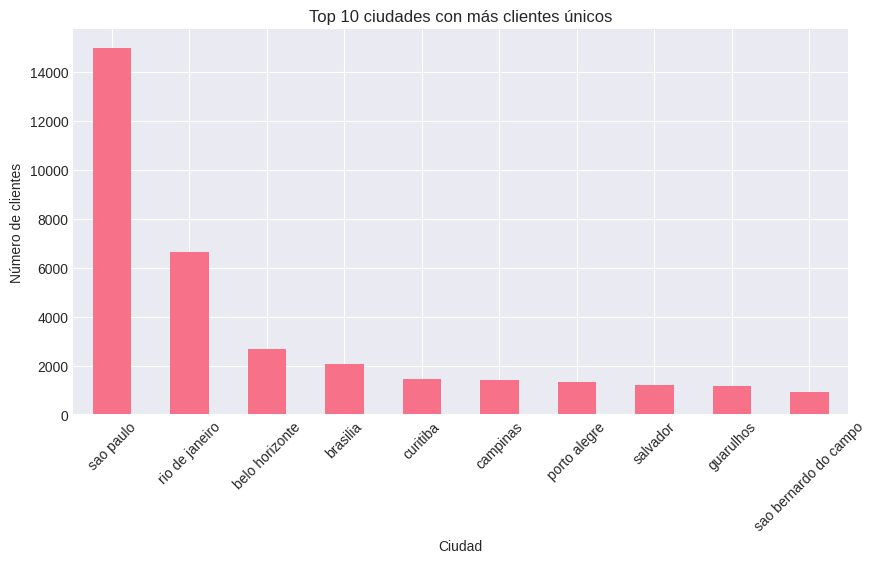

In [ ]:
top_ciudades = df_orders_category.groupby("customer_city")["customer_unique_id"].nunique().sort_values(ascending=False).head(10)
top_ciudades

plt.figure(figsize=(10,5))
top_ciudades.plot(kind="bar")
plt.title("Top 10 ciudades con más clientes únicos")
plt.xlabel("Ciudad")
plt.ylabel("Número de clientes")
plt.xticks(rotation=45)
plt.show()

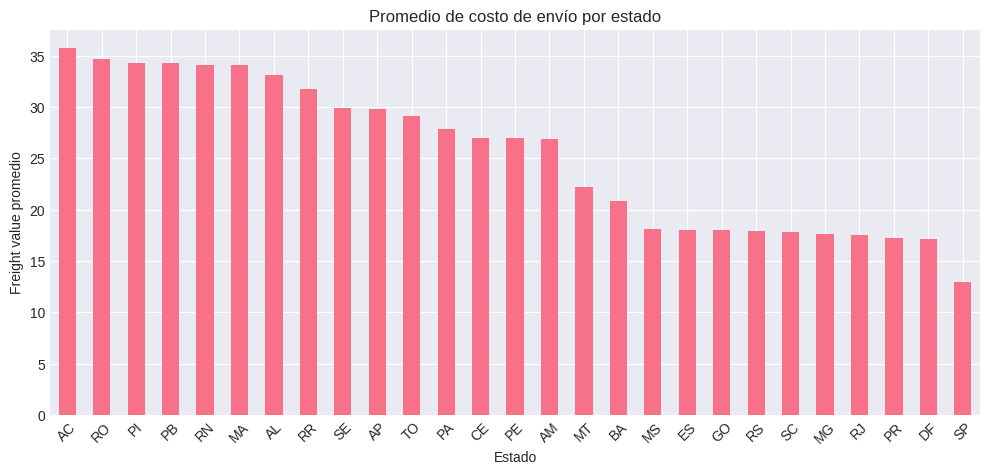

In [ ]:
estado_flete_mediana = df_orders_category.groupby("customer_state")["freight_value"].median().sort_values(ascending=False)
estado_flete_mediana

plt.figure(figsize=(12,5))
estado_flete_mediana.plot(kind="bar")
plt.title("Promedio de costo de envío por estado")
plt.xlabel("Estado")
plt.ylabel("Freight value promedio")
plt.xticks(rotation=45)
plt.show()


###Patrones Temporales

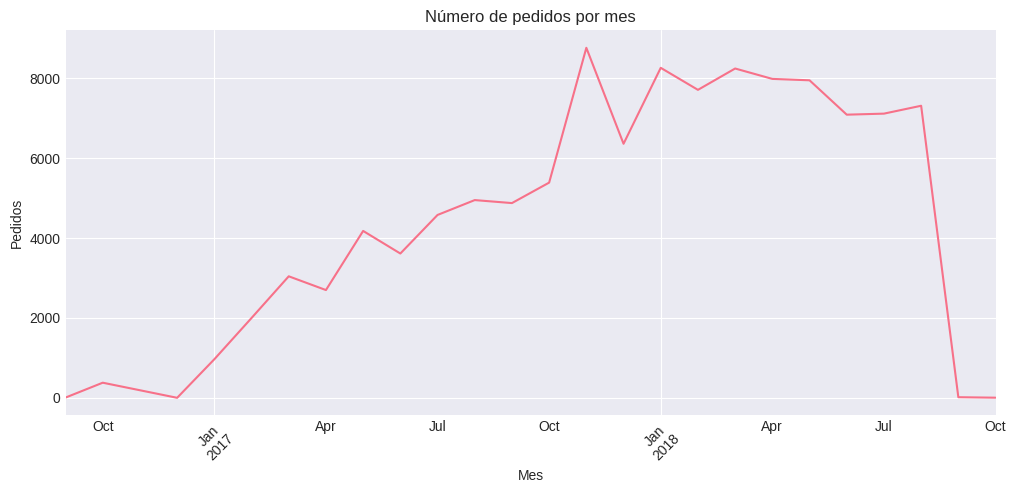

In [ ]:
df_orders_category["order_purchase_timestamp"] = pd.to_datetime(df_orders_category["order_purchase_timestamp"])
df_orders_category["month"] = df_orders_category["order_purchase_timestamp"].dt.to_period("M")

ventas_mes = df_orders_category.groupby("month")["order_id"].count()

ventas_mes

plt.figure(figsize=(12,5))
ventas_mes.plot()
plt.title("Número de pedidos por mes")
plt.xlabel("Mes")
plt.ylabel("Pedidos")
plt.xticks(rotation=45)
plt.show()

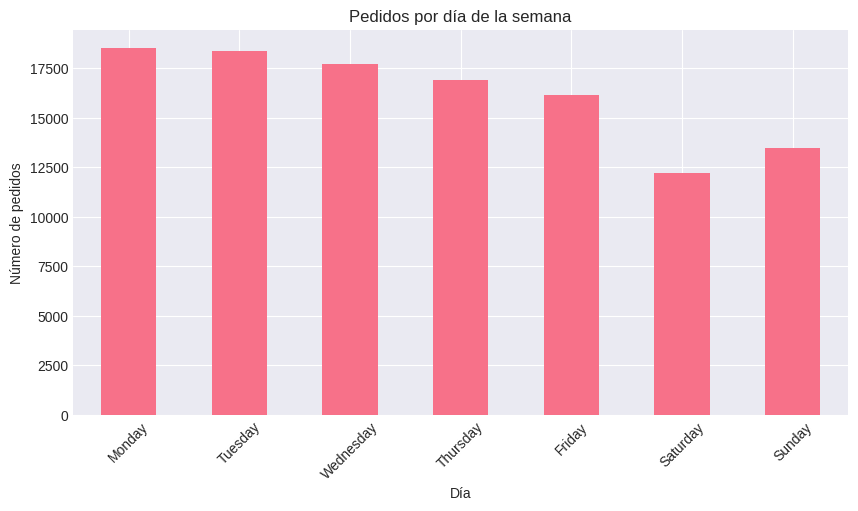

In [ ]:
df_orders_category["day_of_week"] = df_orders_category["order_purchase_timestamp"].dt.day_name()

ventas_dia = df_orders_category["day_of_week"].value_counts()
ventas_dia

orden_dias = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

ventas_dia = ventas_dia.reindex(orden_dias)

plt.figure(figsize=(10,5))
ventas_dia.plot(kind="bar")
plt.title("Pedidos por día de la semana")
plt.xlabel("Día")
plt.ylabel("Número de pedidos")
plt.xticks(rotation=45)
plt.show()